In [1]:
print("START DATASETS PREPARATION")

START DATASETS PREPARATION


# Parameters

In [2]:
which_waterlevel_dataset = ['swan_kuststrook_harmonie', 'waterinfo_rws'][0] # change to second entry for data from waterinfo.rws.nl
verbose = verbose if ('verbose' in locals() or 'verbose' in globals()) else True
print("verbose is %s" % verbose)

verbose is True


# Imports

In [3]:
print(">> imports")

import utils
import xarray as xr
import numpy as np
import matplotlib as mpl

>> imports


# 0: Data input

### trajectories

In [4]:
print(">> load trajectories")

import glob

def load_trajectories(input_path):
  N_traj = len(glob.glob(input_path+"/trajectory_*.nc"))
  trajectories = [xr.open_dataset(input_path+("/trajectory_%d.nc"%i), engine="netcdf4") for i in range(N_traj)]
  return trajectories, N_traj

trajectories, N_traj = load_trajectories("data/out/trajectories/sample_interval_1_rnd_drop_fraction_0.00/")

>> load trajectories


<xarray.Dataset> Size: 388kB
Dimensions:                               (index: 2655, index_original: 2655)
Coordinates:
  * index                                 (index) int64 21kB 0 1 2 ... 2653 2654
  * index_original                        (index_original) int64 21kB 0 ... 2654
Data variables: (12/18)
    time                                  (index) float64 21kB ...
    lon                                   (index) float64 21kB 4.925 ... 5.355
    lat                                   (index) float64 21kB 52.95 ... 53.1
    orientation                           (index) float64 21kB ...
    sst                                   (index) float64 21kB ...
    t                                     (index) float64 21kB ...
    ...                                    ...
    dx                                    (index) float64 21kB ...
    dy                                    (index) float64 21kB ...
    label                                 (index) float64 21kB ...
    grounded                              (index) bool 3kB ...
    dt_section                            (index) float64 21kB ...
    known_minimal_duration_M2_statistics  (index) bool 3kB ...
Attributes:
    i_record:                       0
    i_ts:                           0
    drifter_name:                   <xarray.DataArray 'trajectory' ()> Size: ...
    stdev_position_meters:          6.405357115545444
    units:                          meters for distances, seconds for times, ...
    preprocessing_min_dt:           200
    preprocessing_max_dt:           1700
    preprocessing_min_ts_duration:  5400
    preprocessing_min_ts_nsamp:     36

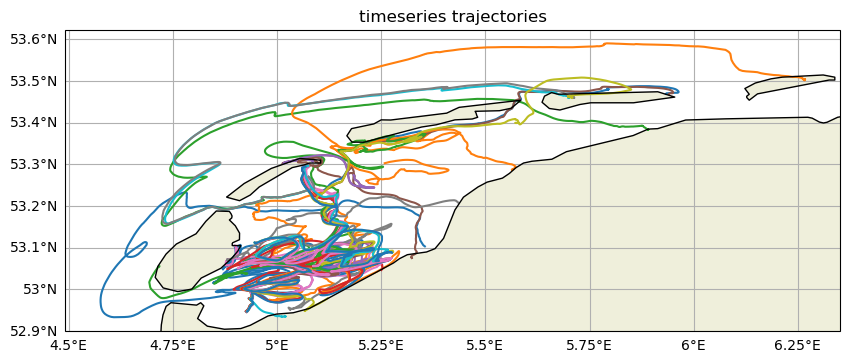

In [5]:
if verbose:
  fig, ax = utils.map_plot("timeseries trajectories")
  for tr in trajectories:
    ax.plot(tr.lon.values, tr.lat.values)

trajectories[0] if verbose else None

### Bathymetry Wadden area

In [6]:
print(">> load bathymetry")

print_data_formatting = True

import numpy as np
import netCDF4
dat = netCDF4.Dataset('data/in/bathymetry_basismonitoringwadden_2019.nc', format='NETCDF4')
bathymetry2019 = {
  'depth' : dat['depth'][:],
  'lon' : dat['lon'][:],
  'lat' : dat['lat'][:],
  'extent' : None
}
lonmin = np.min(bathymetry2019['lon'])
lonmax = np.max(bathymetry2019['lon'])
latmin = np.min(bathymetry2019['lat'])
latmax = np.max(bathymetry2019['lat'])
bathymetry2019['extent'] = ((lonmin,lonmax),(latmin,latmax))

>> load bathymetry


imshow gives 2nd index on X axis and 1st index on Y axis
squares : show orientation of data. darkest is origin, middle is 1st index max, brigthest is 2nd index max
(10139, 5185)
[4.3813815 4.3816843 4.3819876 ... 7.4529176 7.453221  7.4535236]
10139
[52.79103  52.791214 52.791397 ... 53.739372 53.739555 53.73974 ]
5185


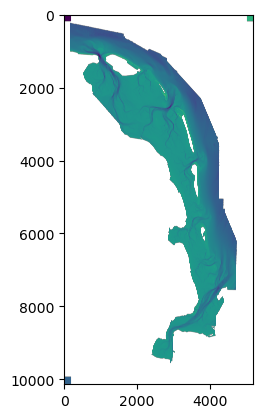

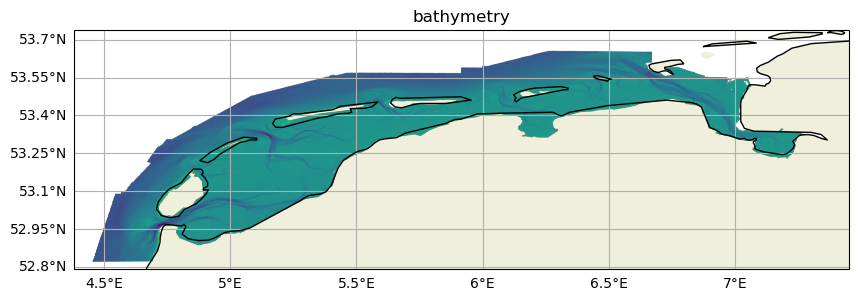

In [7]:
if verbose:
  dat = np.copy(bathymetry2019['depth'])
  dat[0:200,0:200] = -50
  dat[-200:-1,0:200] = -20
  dat[0:200,-200:-1] = 10
  import matplotlib.pyplot as plt
  print("imshow gives 2nd index on X axis and 1st index on Y axis")
  print("squares : show orientation of data. darkest is origin, middle is 1st index max, brigthest is 2nd index max")
  plt.imshow(dat)
  print(dat.shape)
  print(bathymetry2019['lon'])
  print(dat.shape[0])
  print(bathymetry2019['lat'])
  print(dat.shape[1])

  fig, ax = utils.map_plot("bathymetry")
  extent = bathymetry2019['extent']
  extent = (extent[0][0], extent[0][1], extent[1][0], extent[1][1])
  ax.imshow(np.flip(bathymetry2019['depth'].T,axis=0), extent=extent)

### SWAN Waterlevel

>> load SWAN waterlevel
structure before parsing
dict_keys(['time', 'set'])
dict_keys(['lon', 'lat', 'level'])
structure after parsing
dict_keys(['times', 'lons', 'lats', 'vals'])


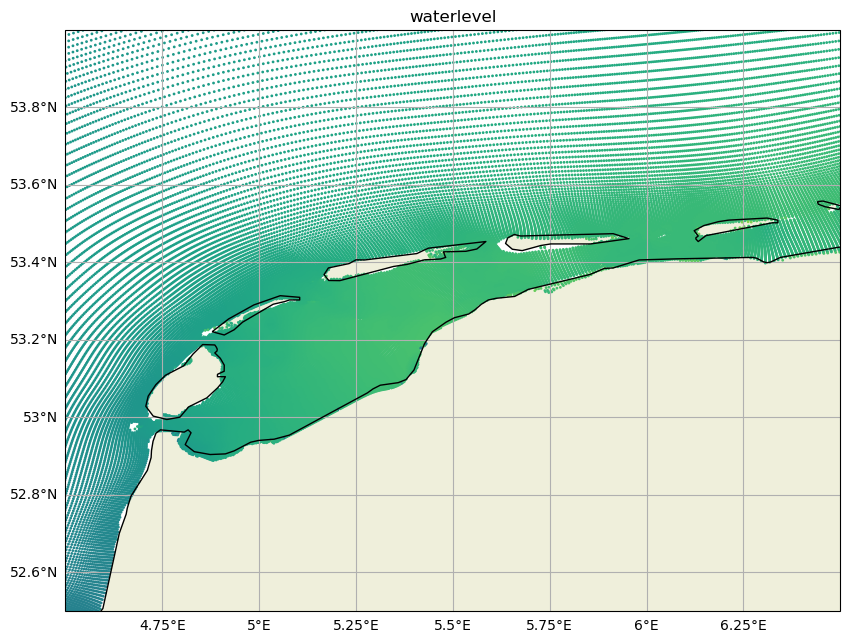

In [8]:
if which_waterlevel_dataset == 'swan_kuststrook_harmonie':
  print(">> load SWAN waterlevel")

  import numpy as np
  swanwaterlevel=np.load("data/in/waterlevel_NAP_from_Nov14_to_Dec05_2023_MATROOS_maps2d_swan_kuststrook_harmonie.npy",allow_pickle=True).tolist()
  if verbose:
    print("structure before parsing")
    print(swanwaterlevel.keys())
    print(swanwaterlevel['set'][0].keys())

  #ni = len(swanwaterlevel['set'][0]['lon'])
  nt = len(swanwaterlevel["time"])
  swanwaterlevel = {
    "times":np.array(swanwaterlevel["time"]),
    "lons":np.array(swanwaterlevel['set'][0]['lon']),
    "lats":np.array(swanwaterlevel['set'][0]['lat']),
    "vals":np.array([swanwaterlevel['set'][it]['level'] for it in range(nt)])
  }
  waterleveldata = swanwaterlevel

  if verbose:
    print("structure after parsing")
    print(swanwaterlevel.keys())
    fig, ax = utils.map_plot("waterlevel")
    ax.scatter(swanwaterlevel['lons'], swanwaterlevel['lats'], c=swanwaterlevel['vals'][6*0], s=1)
    ax.set_xlim([4.5,6.5])
    ax.set_ylim([52.5,54])

### Waterinfo RWS Waterlevels

In [9]:
if which_waterlevel_dataset == 'waterinfo_rws':
  print(">> load RWS waterlevels")
  rwswaterlevel = xr.open_dataset("data/out/rws_waterlevels_14Nov_1Dec.nc", engine="netcdf4")
  rwswaterlevel = rwswaterlevel.rename_vars({"timestamp":"times","lon":"lons","lat":"lats","waterlevel":"vals"})
  waterleveldata = rwswaterlevel
  rwswaterlevel if verbose else None

### Wind ERA5

In [10]:
print(">> load wind")

era5 = xr.open_dataset("data/in/wind_uv_100m_10m_Nov_Dec_2023_ERA5.nc", engine="netcdf4")
era5 if verbose else None

>> load wind


<xarray.Dataset> Size: 879kB
Dimensions:     (valid_time: 1464, latitude: 4, longitude: 9)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 12kB 2023-11-01 ... 2023-12-31T23...
    expver      (valid_time) <U4 23kB ...
  * latitude    (latitude) float64 32B 53.55 53.3 53.05 52.8
  * longitude   (longitude) float64 72B 4.5 4.75 5.0 5.25 5.5 5.75 6.0 6.25 6.5
    number      int64 8B ...
Data variables:
    u100        (valid_time, latitude, longitude) float32 211kB ...
    v100        (valid_time, latitude, longitude) float32 211kB ...
    u10         (valid_time, latitude, longitude) float32 211kB ...
    v10         (valid_time, latitude, longitude) float32 211kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-07-31T13:32 GRIB to CDM+CF via cfgrib-0.9.1...

# 1: Preprocessing

### Preprocessing of Bathymetry: Downsampling, coordinate transformation, direction from gradient

In [ ]:
print(">> preprocessing bathymetry")

vals = bathymetry2019['depth']
axes = (bathymetry2019['lon'], bathymetry2019['lat'])
print("resolution original dataset x~%fm and y~%fm" % ((axes[0][1]-axes[0][0])*111*1000*np.cos(np.deg2rad(axes[1][0])),(axes[1][1]-axes[1][0])*111*1000))

vals_ds, axes_ds = utils.downsample_set_with_rectangular_grid_axes(vals, axes, 5)
print("resolution downscaled x~%fm and y~%fm" % ((axes_ds[0][1]-axes_ds[0][0])*111*1000*np.cos(np.deg2rad(axes_ds[1][0])),(axes_ds[1][1]-axes_ds[1][0])*111*1000))

vals_mesh, coords_mesh, mesh_index_from_grid_indices = utils.get_mesh_from_rectangular_grid_axes(vals_ds, axes_ds)
vals_mesh, coords_mesh = utils.extract_nans_from_mesh(vals_mesh, coords_mesh)
bathymetry = {
  "lons":coords_mesh[:,0],
  "lats":coords_mesh[:,1],
  "vals":vals_mesh,
  "mesh_index_from_grid_indices":mesh_index_from_grid_indices,
  "A_grid_axes": axes_ds,
  "A_grid_vals": vals_ds,
  "coords_mesh_flat":utils.flatten_coords_deg_NE(coords_mesh), #TODO remove and update sampling access
}

directions = utils.get_gradient_direction_NE_from_rectangular_grid_axes(vals_ds, axes_ds)
directions_mesh, coords_directions_mesh, _ = utils.get_mesh_from_rectangular_grid_axes(directions, axes_ds)
directions_mesh, coords_directions_mesh = utils.extract_nans_from_mesh(directions_mesh, coords_directions_mesh)
bathymetry_directions = {
  "lons":coords_directions_mesh[:,0],
  "lats":coords_directions_mesh[:,1],
  "vals":directions_mesh
}

>> preprocessing bathymetry
resolution original dataset x~20.324686m and y~20.324707m
resolution downscaled x~101.718607m and y~101.623535m


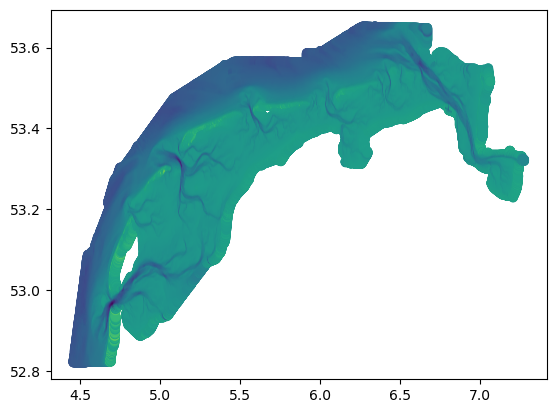

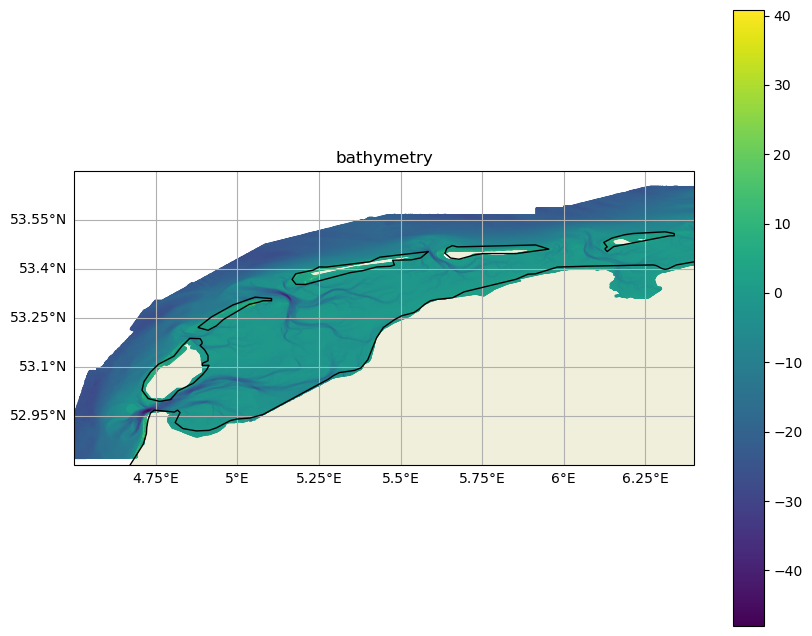

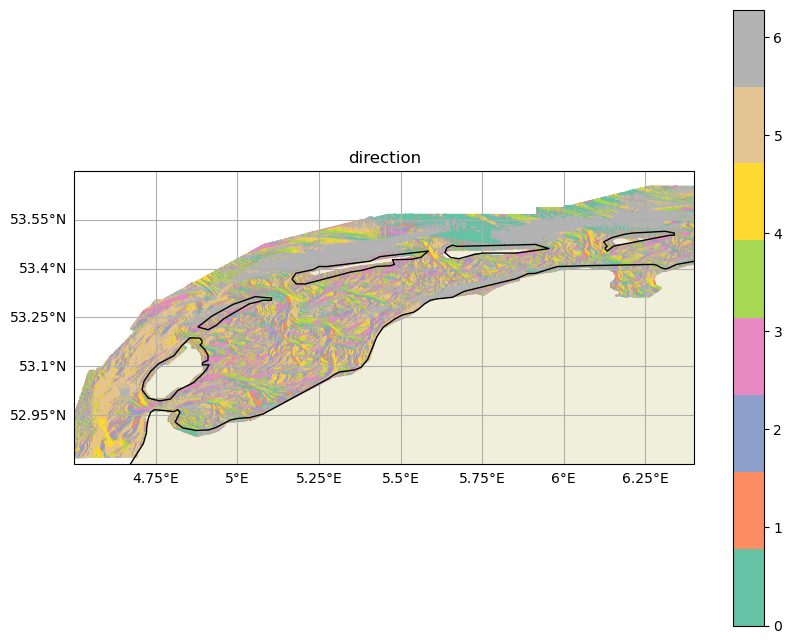

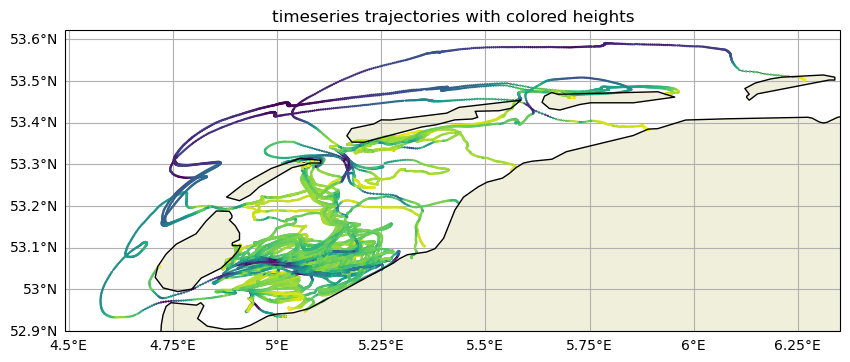

In [12]:
if verbose:
  plt.scatter(coords_mesh[:,0], coords_mesh[:,1], c=vals_mesh)
  plt.show()

  fig, ax = utils.map_plot("bathymetry")
  extent_campagin = {'lon':[4.5,6.4], 'lat':[52.8,53.7]}
  ax.set_xlim(extent_campagin['lon'])
  ax.set_ylim(extent_campagin['lat'])
  plt.scatter(bathymetry["lons"], bathymetry["lats"], c=bathymetry["vals"], s=0.2)
  plt.colorbar()
  plt.show()

  fig, ax = utils.map_plot("direction")
  extent_campagin = {'lon':[4.5,6.4], 'lat':[52.8,53.7]}
  ax.set_xlim(extent_campagin['lon'])
  ax.set_ylim(extent_campagin['lat'])
  # 0 N pi/2 E
  plt.scatter(bathymetry_directions["lons"], bathymetry_directions["lats"], cmap=mpl.colormaps['Set2'], c=bathymetry_directions["vals"], s=0.2, vmin=0.0, vmax=2*np.pi)
  plt.colorbar()
  plt.show()

  fig, ax = utils.map_plot("timeseries trajectories with colored heights")
  coords_mesh_flat = utils.flatten_coords_deg_NE(coords_mesh)
  for tr in trajectories:
    pos_flat = utils.flatten_coords_deg_NE(np.array([tr.lon.values,tr.lat.values]).T)
    N = pos_flat.shape[0]
    hbNAP = np.zeros(N)
    for i in range(N):
      hbNAP[i], _, _, _ = utils.get_closest_eulerian_fast_value_from_mesh(pos_flat[i], vals_mesh, coords_mesh_flat)
      #hbNAP[i] += gauge_hNAP
    nonnan_indices = ~np.isnan(hbNAP)
    ax.plot(tr.lon.values[nonnan_indices], tr.lat.values[nonnan_indices], lw=0.5, color="black")
    ax.scatter(tr.lon.values[nonnan_indices], tr.lat.values[nonnan_indices], c=np.nan_to_num(hbNAP[nonnan_indices]), s=0.5, zorder=2.5)

### Preprocessing of Wind era5: direction and speed from u/v

In [13]:
print(">> preprocessing wind")

nt = era5.valid_time.shape[0]
era5_times = np.array([int(t)/1e9 for t in era5.valid_time],dtype=int)
era5_u10 = np.swapaxes(np.array(era5.u10),1,2)
era5_v10 = np.swapaxes(np.array(era5.v10),1,2)
era5_dir = np.arctan2(era5_u10,era5_v10)%(2*np.pi)
era5_norm = np.linalg.norm(np.array([era5_v10,era5_u10]),axis=0)
era5_lons = np.array(era5.longitude)
era5_lats = np.array(era5.latitude)

_, coords_mesh_wind, _ = utils.get_mesh_from_rectangular_grid_axes(era5_dir[0],(era5_lons,era5_lats))

era5_wind_U = {
  "times":era5_times,
  "lons":coords_mesh_wind[:,0],
  "lats":coords_mesh_wind[:,1],
  "vals":np.array([utils.get_mesh_from_rectangular_grid_axes(era5_u10[i],(era5_lons,era5_lats))[0] for i in range(nt)])
}

era5_wind_V = {
  "times":era5_times,
  "lons":coords_mesh_wind[:,0],
  "lats":coords_mesh_wind[:,1],
  "vals":np.array([utils.get_mesh_from_rectangular_grid_axes(era5_v10[i],(era5_lons,era5_lats))[0] for i in range(nt)])
}

era5_wind_direction = {
  "times":era5_times,
  "lons":coords_mesh_wind[:,0],
  "lats":coords_mesh_wind[:,1],
  "vals":np.array([utils.get_mesh_from_rectangular_grid_axes(era5_dir[i],(era5_lons,era5_lats))[0] for i in range(nt)])
}

era5_wind_speed = {
  "times":era5_times,
  "lons":coords_mesh_wind[:,0],
  "lats":coords_mesh_wind[:,1],
  "vals":np.array([utils.get_mesh_from_rectangular_grid_axes(era5_norm[i],(era5_lons,era5_lats))[0] for i in range(nt)])
}

>> preprocessing wind


<xarray.DataArray 'valid_time' ()> Size: 8B
array('2023-11-01T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    number      int64 8B ...
    valid_time  datetime64[ns] 8B 2023-11-01
    expver      <U4 16B ...
Attributes:
    long_name:      time
    standard_name:  time


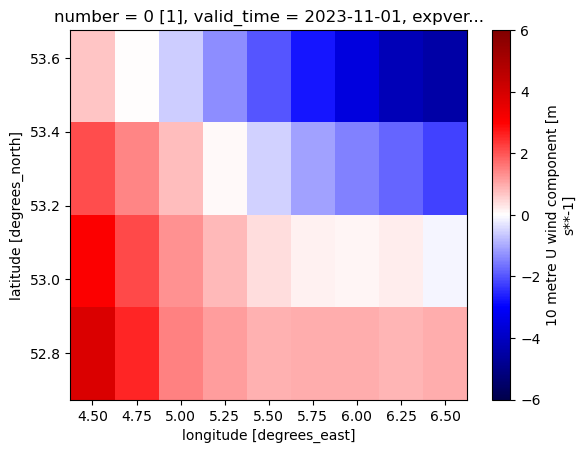

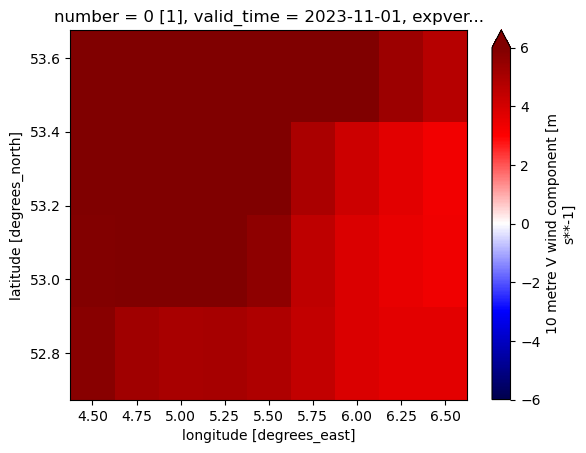

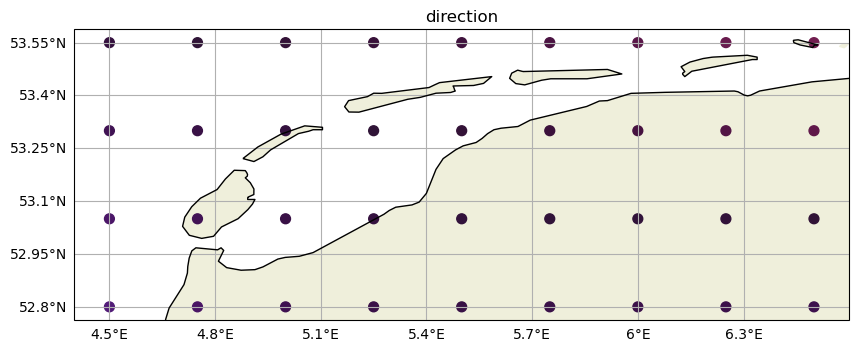

[9.86283273e-02 3.14844400e-01 4.73938286e-01 5.88199139e-01
 4.37219162e-03 2.01450020e-01 3.30025911e-01 4.51671809e-01
 6.20580578e+00 1.02269500e-01 1.97678313e-01 2.89350301e-01
 6.11628485e+00 1.05228387e-02 1.30931467e-01 2.19666779e-01
 6.02238464e+00 6.19804525e+00 6.72390461e-02 1.85046032e-01
 5.89434338e+00 6.06714582e+00 3.33250314e-02 2.14398876e-01
 5.75142384e+00 5.93979311e+00 2.90516745e-02 2.40780577e-01
 5.61669588e+00 5.82316828e+00 5.40761761e-02 2.38645166e-01
 5.52496576e+00 5.68720484e+00 6.24868631e+00 2.62457132e-01]


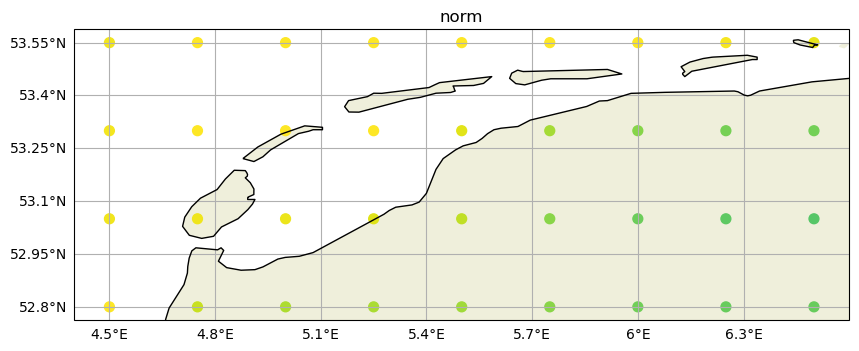

[6.71786451 6.73721266 6.68800879 6.956635   7.28684902 7.11897564
 6.62243795 5.81362534 7.85300255 7.4145093  6.57547998 5.25065756
 8.04975891 7.08795309 6.34203911 5.20594501 7.75583982 6.35778236
 5.65943146 4.99249601 7.27849197 5.13365507 4.50265837 4.51365709
 6.94428873 4.44833803 3.8535912  3.96575832 6.79765081 4.09436798
 3.53449965 3.75991583 6.50285578 3.99949074 3.33026505 3.77190375]


In [14]:
if verbose:
  it=0
  print(era5.valid_time[it])
  era5.u10[it].plot(cmap=mpl.colormaps['seismic'], vmin=-6, vmax=6)
  plt.show()
  era5.v10[it].plot(cmap=mpl.colormaps['seismic'], vmin=-6, vmax=6)
  plt.show()
  fig, ax = utils.map_plot("direction")
  ax.scatter(era5_wind_direction["lons"],era5_wind_direction["lats"],c=era5_wind_direction["vals"][it],s=50,cmap=mpl.colormaps['twilight_shifted'], vmin=0.0, vmax=2*np.pi)
  plt.show()
  print(era5_wind_direction["vals"][it])
  fig, ax = utils.map_plot("norm")
  ax.scatter(era5_wind_speed["lons"],era5_wind_speed["lats"],c=era5_wind_speed["vals"][it],s=50, vmin=-7, vmax=7)
  plt.show()
  print(era5_wind_speed["vals"][it])

# Misc Shared Methods

In [15]:
print(">> defining misc shared methods")

def get_manual_labels_and_indices_where(tr, eventtype=None):
  irecord, its = tr.attrs['i_record'], tr.attrs['i_ts']
  ds = xr.open_dataset("data/out/waddendrifters2023_grounding_events_manual_coding.nc", engine="netcdf4").load()
  inds = (ds.irecord==irecord)&(ds.its==its)&((ds.tag==eventtype) if eventtype else True)
  entries = ds.where(inds,drop=True)
  entries['ind_start'].values = utils.map_to_next_available_index(entries.ind_start.values, tr.index_original.values)[:,1]
  n = int(entries.count(dim='index').tag)
  return entries, n

def get_wind_conditions(lon, lat, time):
  wind_U, _, _ = utils.sample_nearest_mesh_value(era5_wind_U,{"lon":lon, "lat":lat, "time":time})
  wind_V, _, _ = utils.sample_nearest_mesh_value(era5_wind_V,{"lon":lon, "lat":lat, "time":time})
  wind_direction, _, _ = utils.sample_nearest_mesh_value(era5_wind_direction,{"lon":lon, "lat":lat, "time":time})
  wind_speed, _, _ = utils.sample_nearest_mesh_value(era5_wind_speed,{"lon":lon, "lat":lat, "time":time})
  return wind_direction, wind_speed, wind_U, wind_V

>> defining misc shared methods


In [16]:
print("DONE DATASETS PREPARATION")

DONE DATASETS PREPARATION
